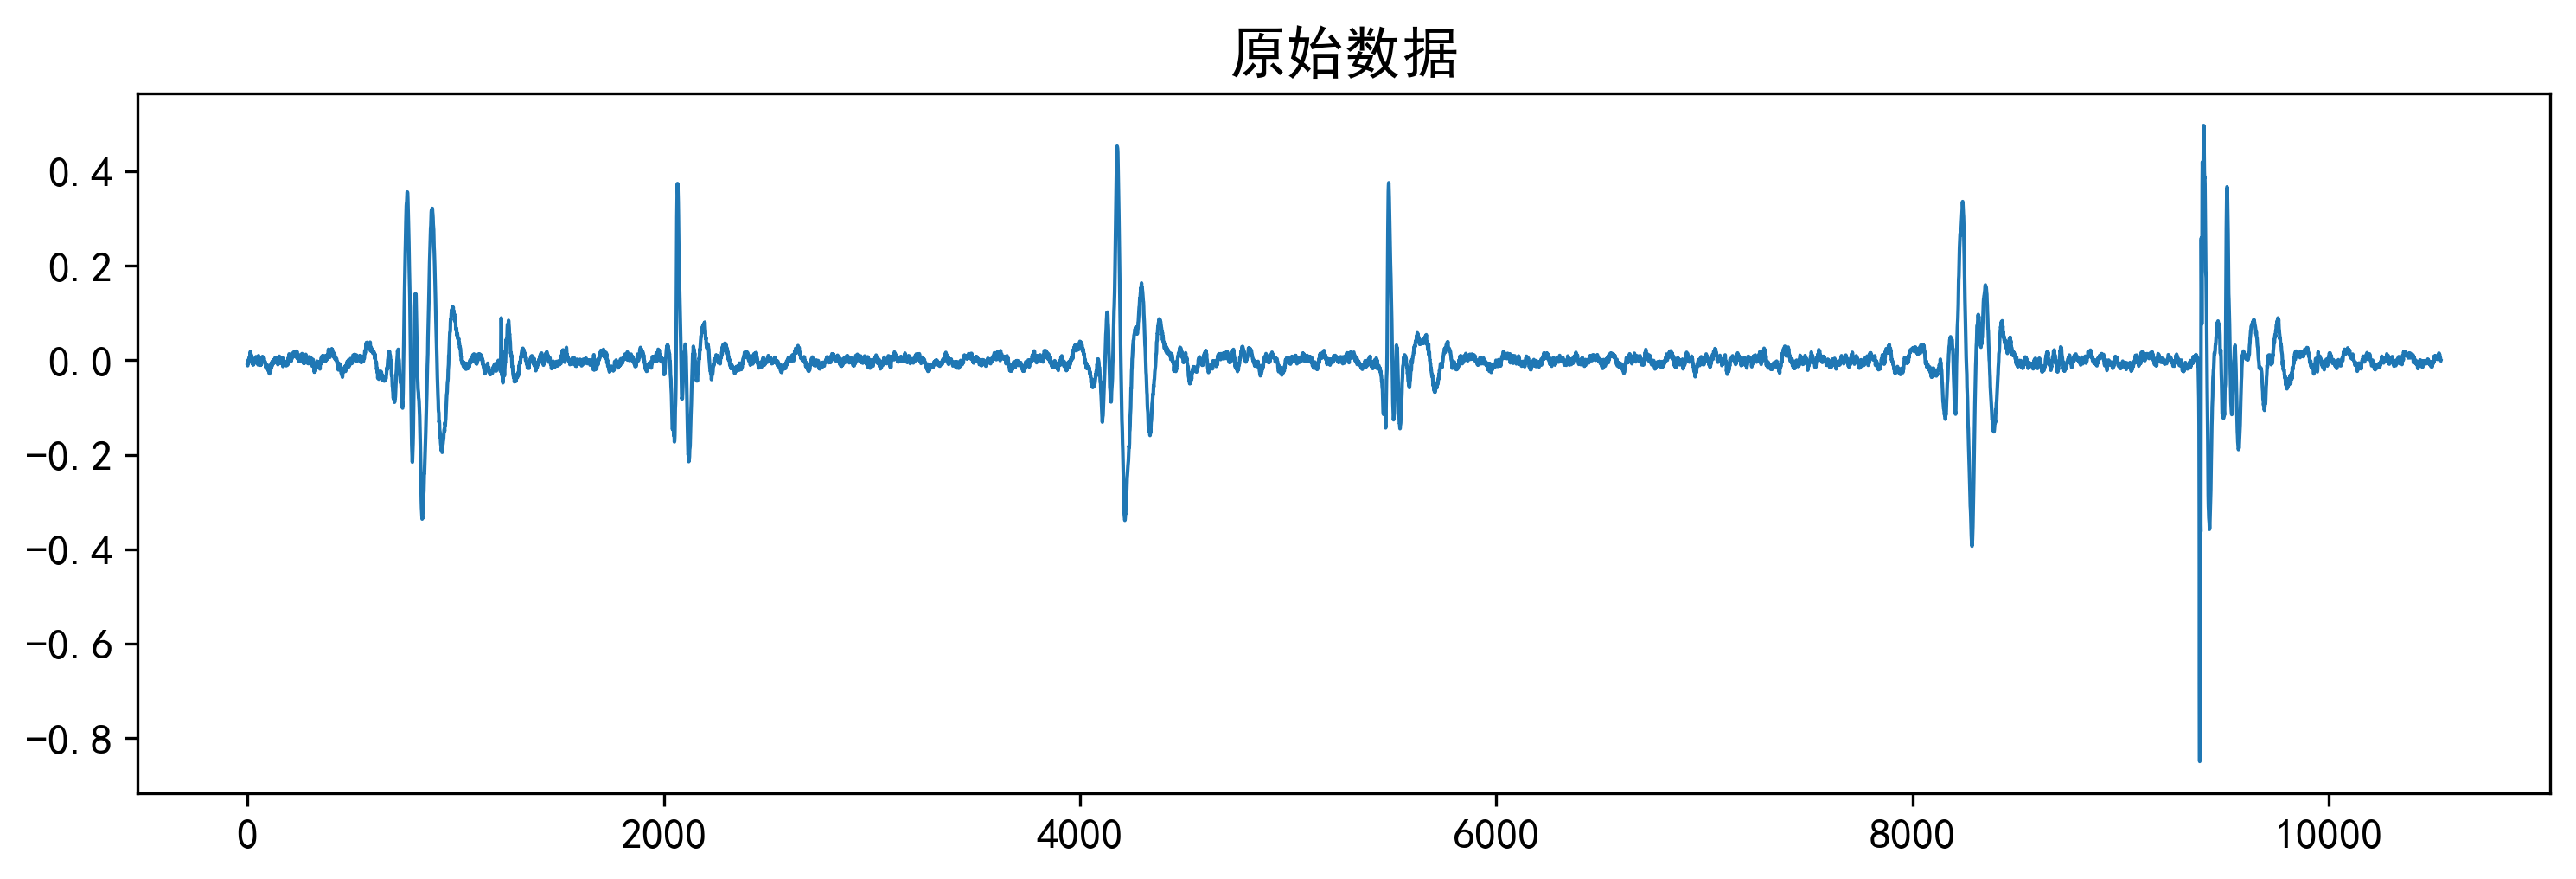

In [60]:
import librosa
import matplotlib.pyplot as plt
import samplerate
import numpy as np

#音频数据可视化（横坐标是样本点数）
def plot_signal(audio_data, title=None):
    plt.figure(figsize=(12, 3.5), dpi=300)
    plt.plot(audio_data, linewidth=1)
    plt.title(title,fontsize = 16)
    plt.tick_params(labelsize=12)
    # plt.grid()
    plt.show()

audio_path = '../HeartSound1/datasets/kaggle/set_b/normal__256_1309351470137_A.wav'
audio_data, fs = librosa.load(audio_path, sr=None)
plot_signal(audio_data, title='原始数据')

In [61]:
fs

4000

## 1.数据预处理

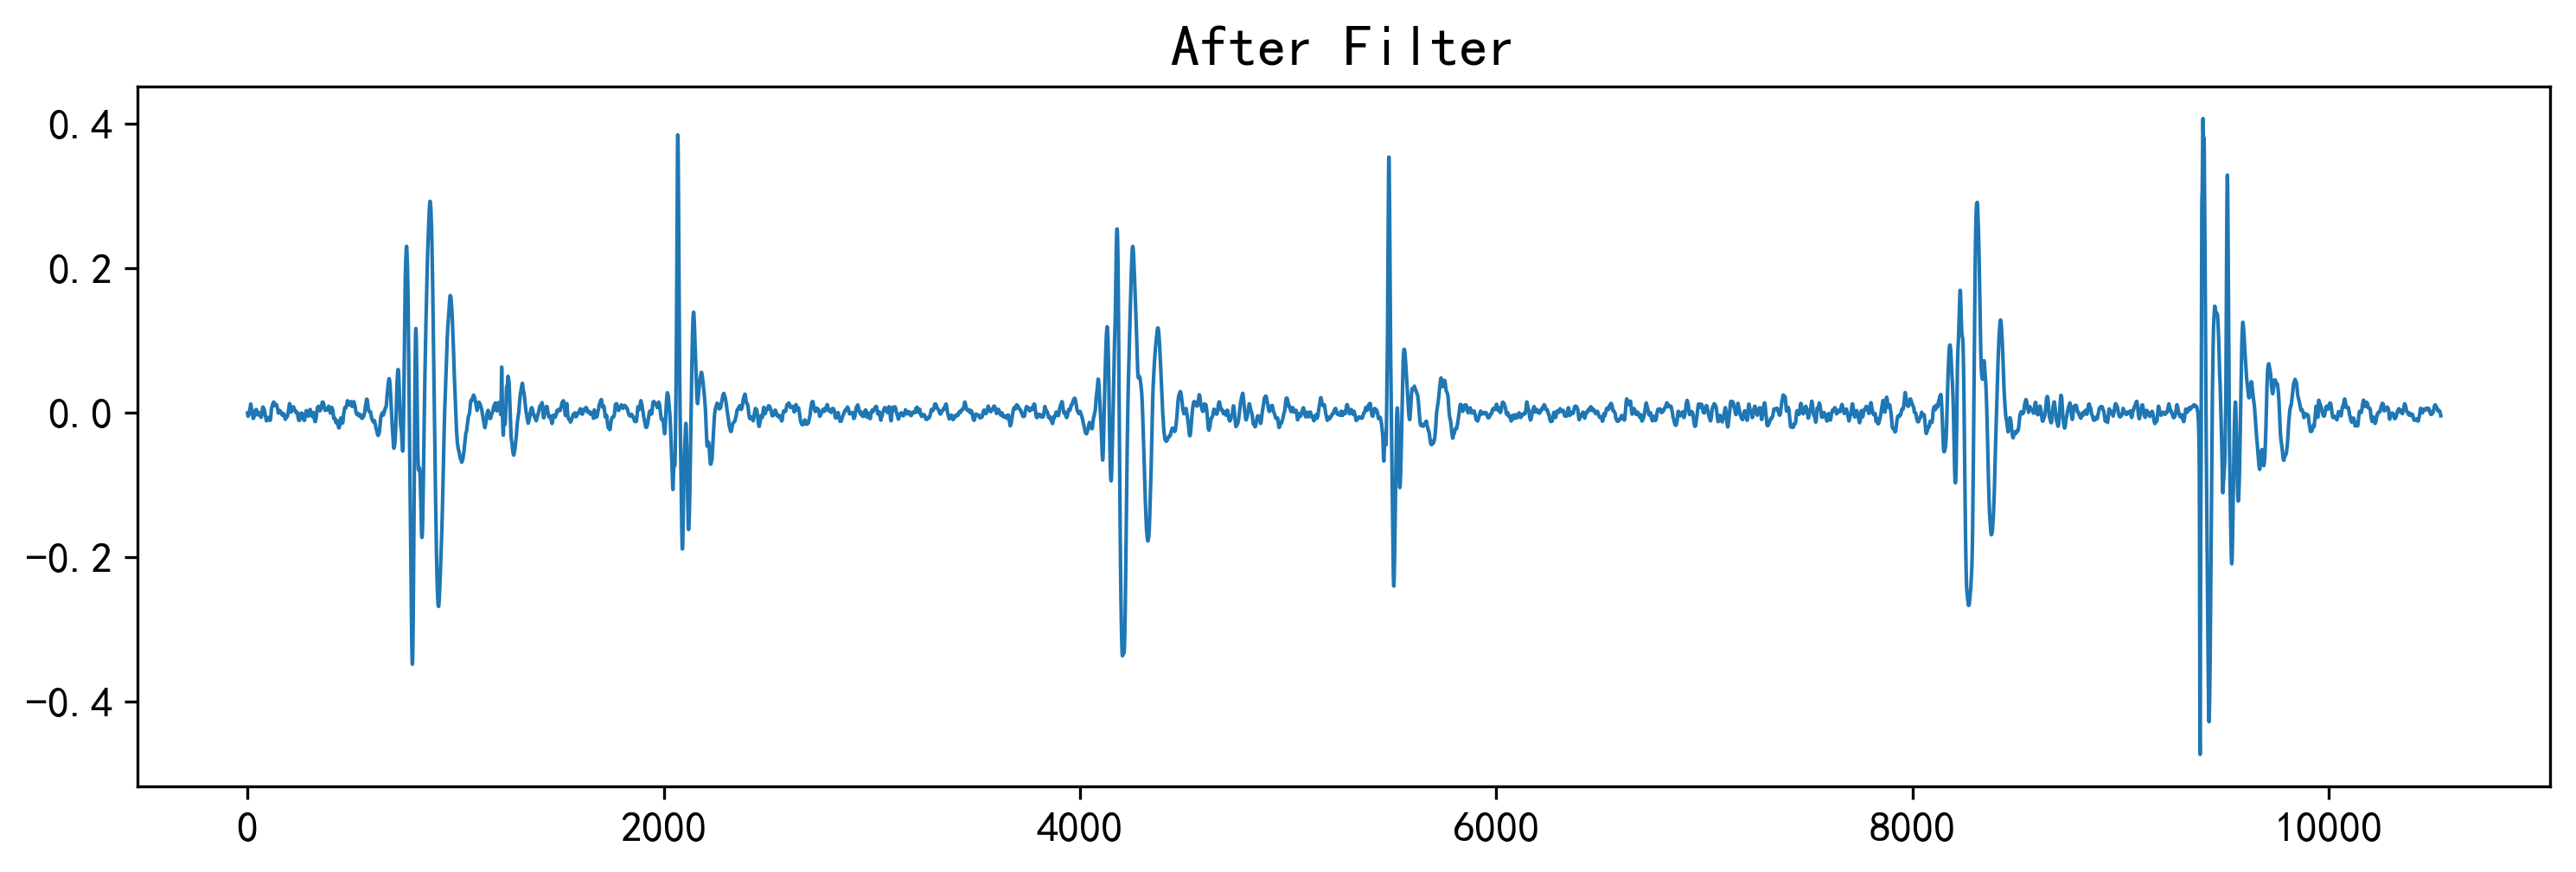

In [62]:
# 去噪（使用二阶的巴特沃夫带通滤波器）
from scipy import signal

def band_pass_filter(original_signal, order, fc1,fc2, fs):
    b, a = signal.butter(N=order, Wn=[2*fc1/fs,2*fc2/fs], btype='bandpass')
    new_signal = signal.lfilter(b, a, original_signal)
    return new_signal

audio_data = band_pass_filter(audio_data, 2, 25, 400, fs)
plot_signal(audio_data, title='After Filter')

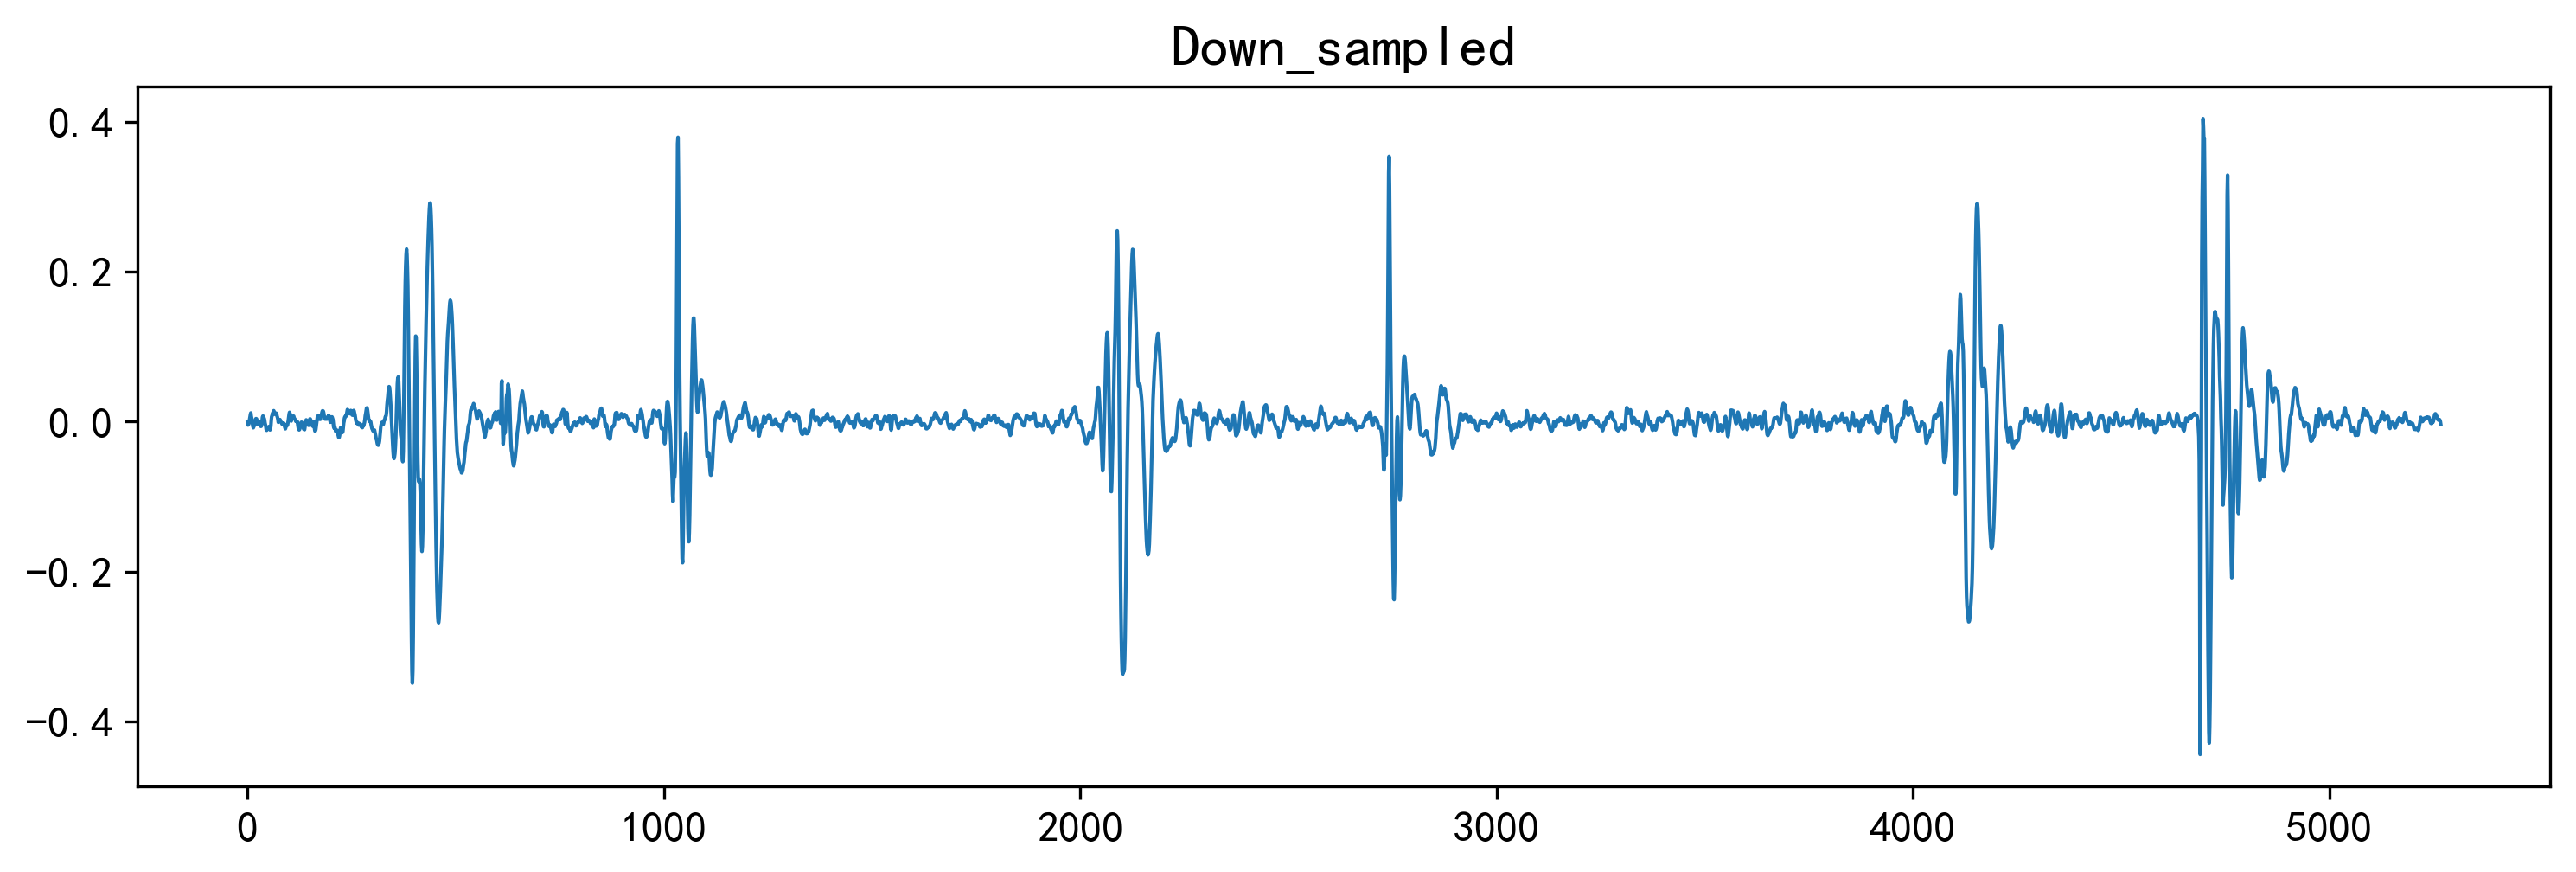

In [63]:
# 重采样到2kHz
def resample_audio(audio_data, fs):
    audio_data = samplerate.resample(audio_data, 2000/fs, 'sinc_best').T
    return audio_data
down_sample_audio_data = resample_audio(audio_data, fs)
plot_signal(down_sample_audio_data, title='Down_sampled')

In [64]:
# 数据增强
def add_noise1(x, w=0.004):  # 加噪
    # w：噪声因子
    output = x + w * np.random.normal(loc=0, scale=1, size=len(x))
    return output


def add_noise2(x, snr=50):  # 控制信噪比
    # snr：生成的语音信噪比
    P_signal = np.sum(abs(x) ** 2) / len(x)  # 信号功率
    P_noise = P_signal / 10 ** (snr / 10.0)  # 噪声功率
    return x + np.random.randn(len(x)) * np.sqrt(P_noise)


def time_shift(x, shift):  # 波形移动
    # shift：移动的长度
    return np.roll(x, int(shift))


def time_stretch(x, rate):  # 波形拉伸
    # rate：拉伸的尺寸，
    # rate > 1 加快速度
    # rate < 1 放慢速度
    return librosa.effects.time_stretch(x, rate)

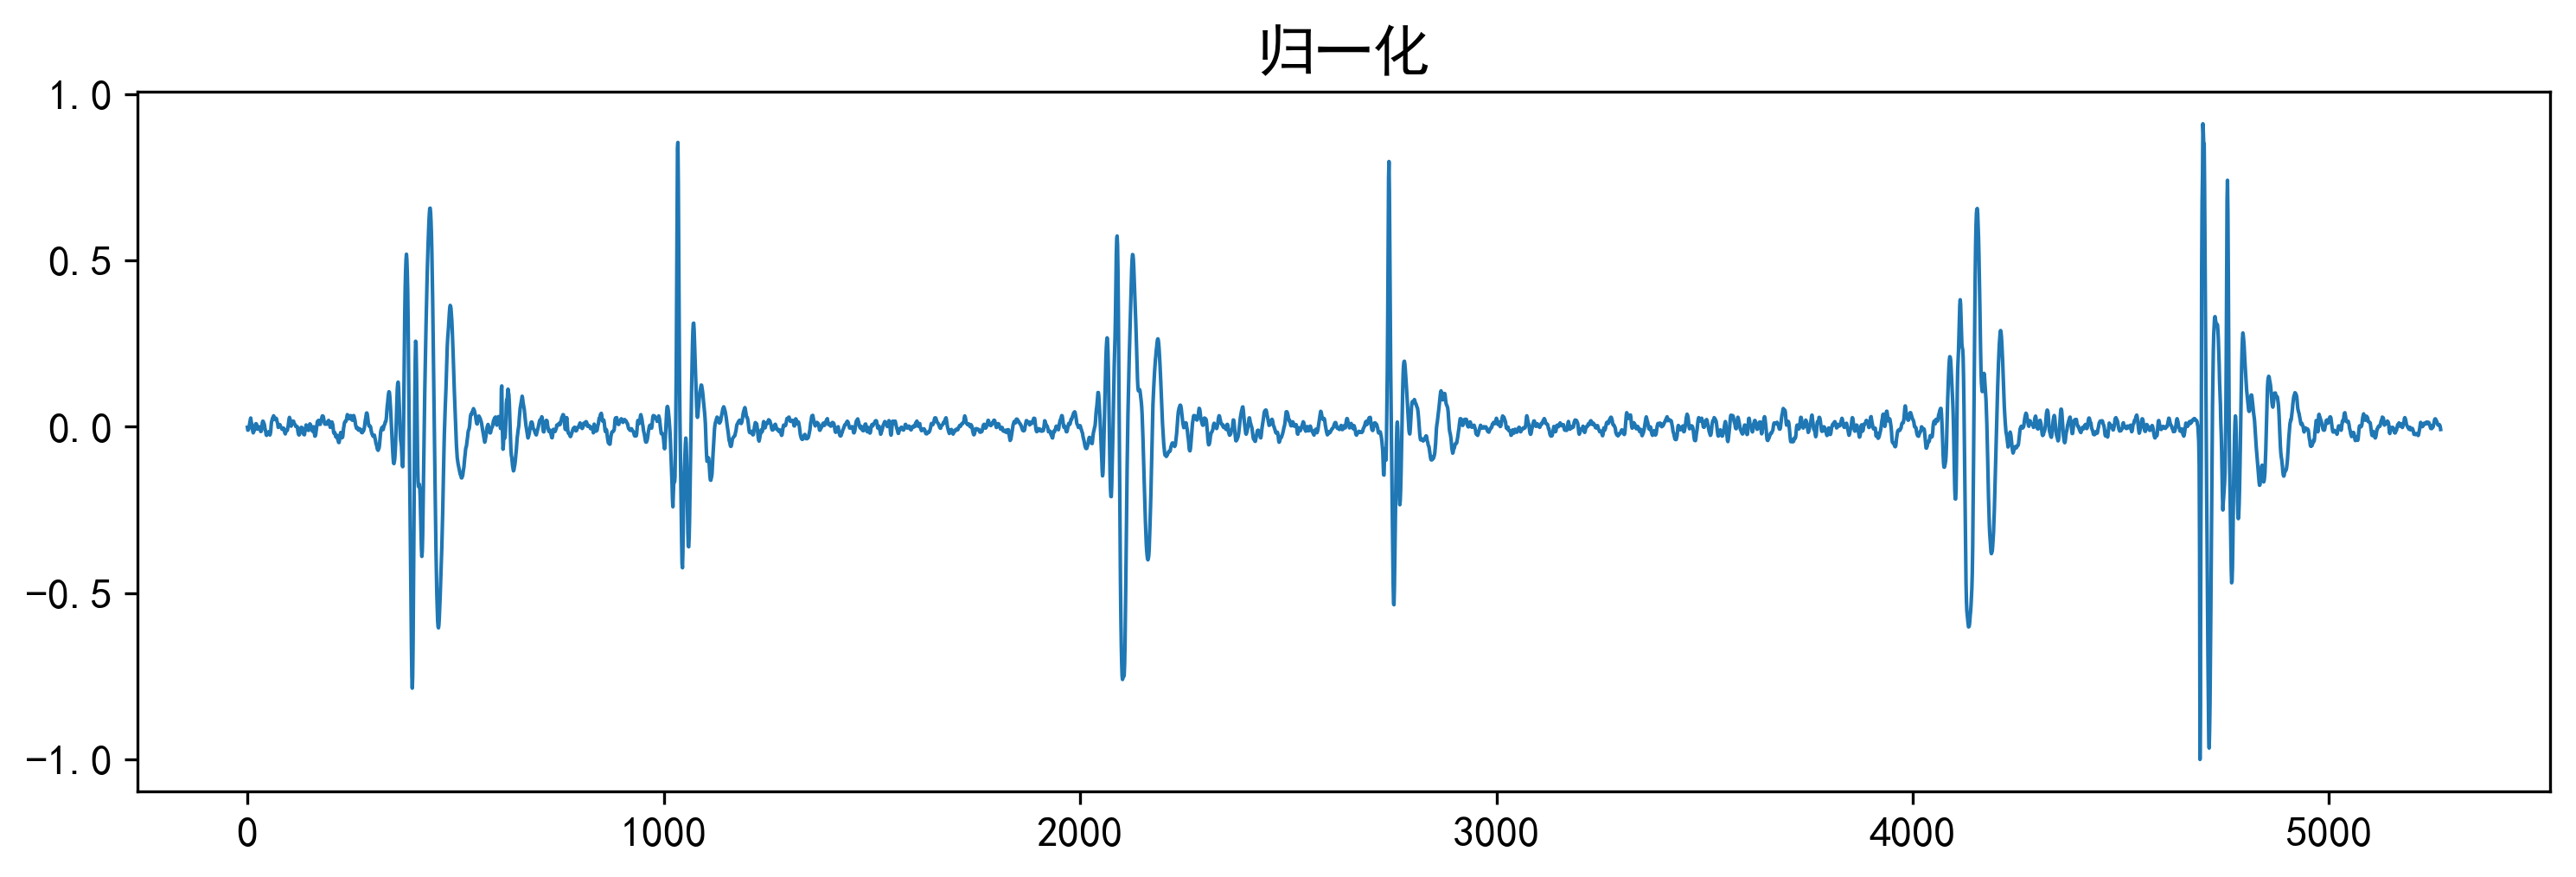

In [65]:
# 归一化
def normalize(x):
    return x / np.max(np.abs(x))

down_sample_audio_data = normalize(down_sample_audio_data)
plot_signal(down_sample_audio_data, title='归一化')

In [66]:
# 信号分割
def segment_signal(signal):
    # signal: 输入信号
    
    segment_length = 3000  
    segments = []
    
    for i in range(0, len(signal), segment_length):
        segment = signal[i:i + segment_length]
        if len(segment) == segment_length:
            segments.append(segment)
    
    return np.array(segments)

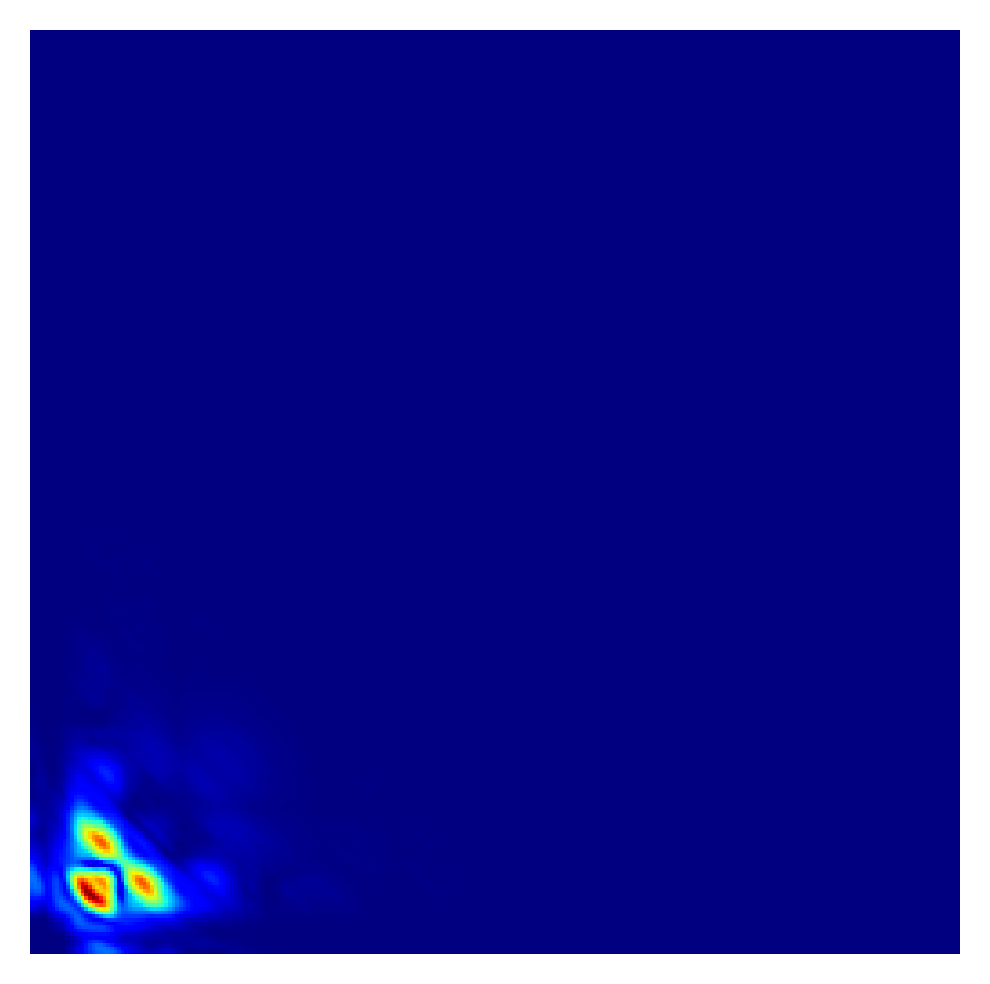

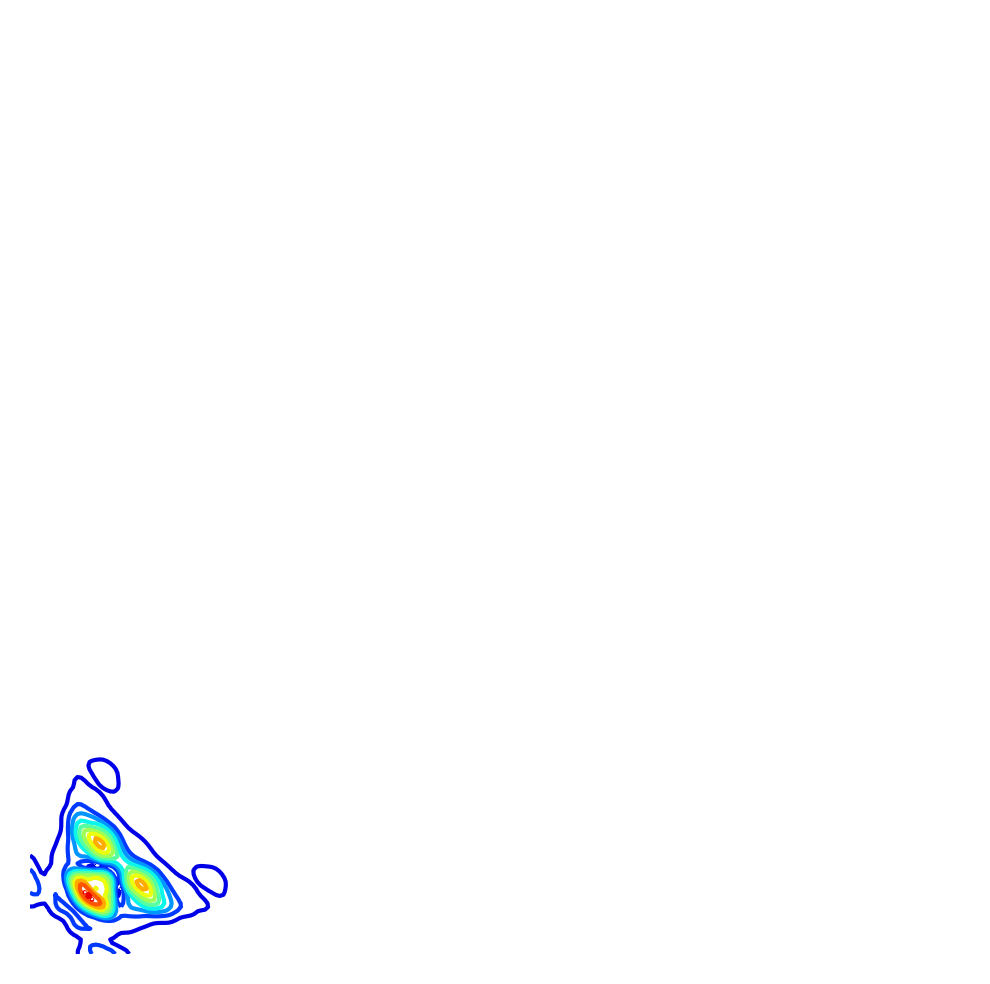

In [67]:
import import_ipynb
# from MyPreprocess import *
from Extract_bispectrum import polycoherence,plot_polycoherence

ex_audio_data = down_sample_audio_data[:3000]
freq1, freq2, bi_spectrum = polycoherence(ex_audio_data, nfft=1024, nperseg=256, noverlap = 128, fs = 2000, norm=None)
bi_spectrum = np.array(abs(bi_spectrum))  # calculate bi_spectrum
bi_spectrum = 255 * (bi_spectrum - np.min(bi_spectrum)) / (np.max(bi_spectrum) - np.min(bi_spectrum))
plot_polycoherence(freq1, freq2, bi_spectrum)
# 修改尺寸以便于投入神经网络
# bi_spectrum = bi_spectrum.reshape((256, 256, 1))
# 至此，完成特征提取过程

In [ ]:
import librosa
import matplotlib.pyplot as plt
import samplerate
import numpy as np
from scipy import signal

# 设置matplotlib正常显示中文和负号
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用黑体显示中文
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

# 音频数据可视化（横坐标是样本点数）
def plot_signal(audio_data, title=None, ax=None):
    if ax is None:
        ax = plt.gca()
    ax.plot(audio_data, linewidth=1)
    ax.set_title(title, fontsize=16)
    ax.tick_params(labelsize=12)

# 去噪（使用二阶的巴特沃夫带通滤波器）
def band_pass_filter(original_signal, order, fc1, fc2, fs):
    b, a = signal.butter(N=order, Wn=[2 * fc1 / fs, 2 * fc2 / fs], btype='bandpass')
    new_signal = signal.lfilter(b, a, original_signal)
    return new_signal

# 重采样到2kHz
def resample_audio(audio_data, fs):
    audio_data = samplerate.resample(audio_data, 2000 / fs, 'sinc_best').T
    return audio_data

# 数据增强
def add_noise1(x, w=0.004):  # 加噪
    output = x + w * np.random.normal(loc=0, scale=1, size=len(x))
    return output

def add_noise2(x, snr=50):  # 控制信噪比
    P_signal = np.sum(abs(x) ** 2) / len(x)  # 信号功率
    P_noise = P_signal / 10 ** (snr / 10.0)  # 噪声功率
    return x + np.random.randn(len(x)) * np.sqrt(P_noise)

def time_shift(x, shift):  # 波形移动
    return np.roll(x, int(shift))

def time_stretch(x, rate):  # 波形拉伸
    return librosa.effects.time_stretch(x, rate)

# 归一化
def normalize(x):
    return x / np.max(np.abs(x))

# 设置图形显示的尺寸
fig, axes = plt.subplots(2, 3, figsize=(30, 20), dpi=300)

# 读取音频文件
audio_path = '../HeartSound1/datasets/kaggle/set_b/normal__256_1309351470137_A.wav'  
audio_data, fs = librosa.load(audio_path, sr=None)

# 原始音频
plot_signal(audio_data, title='原始音频', ax=axes[0, 0])

# 去噪处理
audio_data_filtered = band_pass_filter(audio_data, 2, 25, 400, fs)
plot_signal(audio_data_filtered, title='去噪处理', ax=axes[0, 1])

# 重采样到2kHz
down_sample_audio_data = resample_audio(audio_data_filtered, fs)
plot_signal(down_sample_audio_data, title='重采样到2kHz', ax=axes[0, 2])

# 数据增强：加噪声
noisy_audio_1 = add_noise1(down_sample_audio_data)
plot_signal(noisy_audio_1, title='加噪声', ax=axes[1, 0])

# 数据增强：加噪声2（控制信噪比）
noisy_audio_2 = add_noise2(noisy_audio_1)
plot_signal(noisy_audio_2, title='控制信噪比', ax=axes[1, 1])

# 归一化
down_sample_audio_data_normalized = normalize(noisy_audio_2)
plot_signal(down_sample_audio_data_normalized, title='归一化', ax=axes[1, 2])

plt.tight_layout()
plt.show()


In [69]:
# # 切割过程可视化
# total_num = segment_signal(down_sample_audio_data).shape[0]  

# fig = plt.figure(figsize=(12, 5), dpi=300)
# ax1 = fig.add_subplot(2,1,1)
# plt.plot(down_sample_audio_data,linewidth=1)
# plt.title('Cut Audio With 50%Overlap (2000Hz)',fontsize=16)
# plt.tick_params(labelsize=12)
# plt.ylim([-1.2,1.2])
# plt.grid()
# for j in range(int(total_num)):
#     plt.vlines(j*3000, -1.2, 1.2, color="red",linestyle='--',linewidth=1.1)
# ax2 = fig.add_subplot(2, 1, 2)
# plt.plot(down_sample_audio_data, linewidth=1)
# for j in range(int(total_num)):
#     plt.vlines(j*3000 + 1500, -1.2, 1.2, color="green",linestyle='--',linewidth=1.1)
# plt.ylim([-1.2,1.2])
# plt.grid()
# plt.show()